In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")  # Tuliskan nama lengkap Anda
print("103112430182")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print()
print("Praktikum 12: https://colab.research.google.com/drive/1m7JwkK7sn6uyhQm3CP_w8liyi7r7r109?usp=sharing") # Link collab Praktikum 12
print("Praktikum 13: https://colab.research.google.com/drive/162bN_W4E_3iB1yEsHWQVMSXObccPw7II?usp=sharing") # Link collab Praktikum 13
print("Jurnal 12 13: https://colab.research.google.com/drive/1ekDsZM3UdwoDbhteLd5XWkolBJKab0xR?usp=sharing") # Link collab Jurnal
print("Link GitHub : https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2013%20PENGENALAN%20LIBRARY%20SCIKIT-FUZZY") # Link GitHub

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06

Praktikum 12: https://colab.research.google.com/drive/1m7JwkK7sn6uyhQm3CP_w8liyi7r7r109?usp=sharing
Praktikum 13: https://colab.research.google.com/drive/162bN_W4E_3iB1yEsHWQVMSXObccPw7II?usp=sharing
Jurnal 12 13: https://colab.research.google.com/drive/1ekDsZM3UdwoDbhteLd5XWkolBJKab0xR?usp=sharing
Link GitHub : https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2013%20PENGENALAN%20LIBRARY%20SCIKIT-FUZZY


## 13.1. Instalasi Scikit-Fuzzy

Scikit-Fuzzy tidak tersedia pada *package* Anaconda secara *default*. Berikut adalah langkah-langkah untuk menambahkan *package* Scikit-Fuzzy pada *environment* Anaconda:

1. Buka **Anaconda Prompt** untuk Windows atau **Terminal** pada MacOs.
2. Jalankan perintah `pip install scikit-fuzzy`.
3. Jika berhasil, maka akan terlihat tampilan seperti Gambar 21.

In [2]:
# Instalasi scikit-fuzzy (jalankan jika belum terinstall)
!pip install scikit-fuzzy

## 13.2. Membuat Program dengan *Library* Scikit-Fuzzy

### 13.2.1. Inisialisasi Variabel *Fuzzy*

Dalam *fuzzy logic*, terdapat dua variabel yang mendefinisikan bagaimana *fuzzy system* beroperasi dan menghasilkan keputusan. Variabel tersebut terdiri atas **variabel *input*** dan **variabel *output***. Variabel *input* adalah nilai atau data yang diberikan kepada *fuzzy system* untuk diproses, variabel ini mewakili kondisi atau faktor-faktor yang mempengaruhi hasil akhir dalam suatu sistem. Sedangkan variabel *output* adalah hasil atau keputusan yang dihasilkan oleh *fuzzy system* setelah melalui aturan-aturan *fuzzy* yang telah ditentukan.

Dalam Scikit-Fuzzy, variabel *input* didefinisikan dengan `ctrl.Antecedent()` yang berperan sebagai *input* dalam *fuzzy logic*. Berikut adalah parameter yang digunakan dalam `ctrl.Antecedent()`:

- `universe`: Parameter ini adalah rentang atau domain nilai yang dapat diambil oleh variabel *fuzzy*. Parameter ini didefinisikan dengan NumPy *array* dengan menggunakan `np.arange(start, stop, step)`, yang menunjukkan rentang nilai dari `start` hingga `stop` dengan langkah `step`.
- `label`: Label atau nama yang diberikan untuk variabel *fuzzy* akan digunakan untuk referensi dalam aturan *fuzzy logic*.

Berikut adalah contoh penggunaan `ctrl.Antecedent()`:

In [3]:
from skfuzzy import control as ctrl
import numpy as np

# Pendefinisian variabel kontrol quality
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')

Pada kode di atas, `quality` adalah variabel *fuzzy* yang dapat memiliki nilai hingga 0 hingga 10 dan variabel *fuzzy* ini diberikan label `quality`.

Sedangkan variable *output*, Scikit-Fuzzy menyediakan `ctrl.Consequent()` yang digunakan untuk mendefinisikan variabel *fuzzy* yang berperan sebagai *output* dari sistem yang akan ditentukan berdasarkan *input* yang diberikan dan aturan *fuzzy logic* yang telah ditentukan. `ctrl.Consequent()` memiliki parameter yang sama seperti `ctrl.Antecedent()`.

Berikut adalah implementasi dan contoh dari `ctrl.Consequent()`:

In [4]:
from skfuzzy import control as ctrl

# Pendefinisian variabel output tip
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

Dalam contoh di atas, `tip` merupakan variabel *fuzzy* yang dapat memiliki nilai 0 hingga 25, dan diberi label "*tip*" sebagai penanda.

Berikut adalah hubungan antara `ctrl.Antecedent()` sebagai variabel *input* dan `ctrl.Consequent()` sebagai variabel *output*:

- `ctrl.Antecedent()` berfungsi sebagai variabel *input* yang akan dievaluasi dalam aturan *fuzzy*, sedangkan `ctrl.Consequent()` adalah variabel *output* yang nilainya akan dipengaruhi oleh evaluasi aturan-aturan tersebut.
- Dalam sebuah sistem kontrol *fuzzy*, aturan-aturan didefinisikan untuk menghubungkan nilai dari `ctrl.Antecedent()` ke `ctrl.Consequent()`. Misalnya **"Jika kualitas (*Antecedent*) buruk, maka tip (*Consequent*) rendah"**.

### 13.2.2. Membuat Fungsi Keanggotaan

Fungsi keanggotaan dalam *fuzzy logic* adalah kurva yang mendefinisikan bagaimana setiap titik dalam *input* atau *output* dipetakan ke derajat keanggotaan dalam himpunan *fuzzy*. Fungsi ini mengubah nilai numerik menjadi nilai *fuzzy* yang menunjukkan seberapa besar suatu nilai termasuk dalam kategori tertentu, seperti "rendah", "sedang", atau "tinggi".

Dalam scikit-fuzzy, `.trimf()` merupakan salah satu fungsi untuk membuat keanggotaan dalam *fuzzy logic* yang digunakan untuk menentukan derajat keanggotaan suatu nilai dalam himpunan *fuzzy*. ***Trimf*** adalah singkatan dari *Triangular Membership Function* (Fungsi keanggotaan segitiga).

Fungsi ini digunakan untuk memetakan *fuzzy system* untuk memetakan *input* ke dalam nilai keanggotaan antara 0 dan 1. Fungsi ini paling sederhana dan banyak digunakan karena bentuknya yang mudah dipahami.

Fungsi `trimf()` didefinisikan sebagai berikut:

In [5]:
import skfuzzy as fuzz

# Pendefinisian keanggotaan pada quality
# quality['membership'] = fuzz.trimf(x, [a, b, c])

Berikut adalah penjelasan dari parameter `trimf()`:

- `x`: *Array* dari nilai input, ini bisa diambil dari *Antecedent* atau *Consequent* yang sudah dibuat.
- `a` (*Lower Bound*): Titik awal segitiga, di mana derajat keanggotaan mulai dari 0.
- `b` (*Peak / Middle Point*): Titik puncak segitiga, di mana derajat keanggotaan mencapai 0.
- `c` (*Upper Bound*): Titik akhir segitiga, di mana derajat keanggotaan kembali ke 0.

Fungsi keanggotaan yang sudah dibuat dapat divisualisasikan dengan cara berikut:

In [6]:
# Menampilkan visualisasi dari fungsi keanggotaan yang sudah diberikan
# quality.view()

Hasilnya adalah grafik dengan bentuk segitiga yang menunjukkan derajat keanggotaan untuk setiap nilai dalam rentang yang diberikan.

Berikut adalah implementasi dan contoh untuk membuat fungsi keanggotaan:

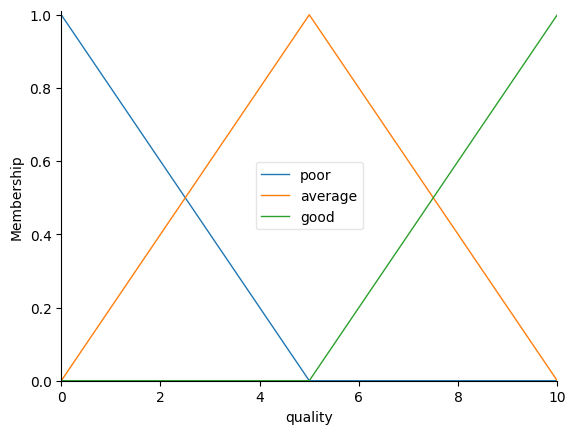

In [7]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

# Mendefinisikan input variabel
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')

# Membuat fungsi keanggotaan untuk quality
quality['poor']    = fuzz.trimf(quality.universe, [0, 0, 5])
quality['average'] = fuzz.trimf(quality.universe, [0, 5, 10])
quality['good']    = fuzz.trimf(quality.universe, [5, 10, 10])

# Menampilkan visualisasi keanggotaan quality
quality.view()

### 13.2.3. Penentuan Aturan *Fuzzy*

Aturan *fuzzy* adalah komponen penting dalam sistem *fuzzy logic* yang digunakan untuk menghubungkan *input* dengan *output* berdasarkan logika yang ditentukan. Aturan *fuzzy* dinyatakan dalam bentuk **"Jika … Maka …"** yang menghubungkan kondisi *input* dengan hasil *output*.

Dalam scikit-fuzzy, aturan tersebut didefinisikan dengan `.Rule()`. Parameter `.Rule()` terdiri dari *Antecedent* atau syarat / kondisi dan *Consequent* atau hasil / tindakan. Berikut adalah implementasi dari `.Rule()`:

In [8]:
# quality, service = Antecedent, tip = Consequent
# rule1 = ctrl.Rule(quality['poor'] | service['poor'], tip['low'])

Arti dari rule di atas adalah: **"Jika quality atau service bernilai poor maka tip menjadi low"**.

Berikut adalah operator logika dalam `.Rule()` pada parameter *Antecedent*:

- `&` (*AND*): Menghubungkan dua kondisi yang keduanya harus terpenuhi agar aturan terpicu.
- `|` (*OR*): Menghubungkan dua kondisi di mana salah satu kondisi yang terpenuhi sudah cukup untuk memicu aturan.
- `~` (*NOT*): Membalik kondisi dari variabel *fuzzy*.

Setelah aturan didefinisikan, aturan-aturan tersebut dimasukkan ke dalam *fuzzy system* menggunakan `.ControlSystem()`, yang kemudian dapat disimulasikan untuk menghasilkan *output* berdasarkan *input* yang diberikan. Objek untuk mensimulasikan *fuzzy system* juga harus dibuat menggunakan `.ControlSystemSimulation()`. Berikut adalah implementasi `.ControlSystemSimulation()`:

In [9]:
# Membuat control system dari beberapa aturan yang sudah dibuat
# tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
# tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

Berikut adalah contoh implementasi dari penentuan aturan *fuzzy*:

In [10]:
# Pendefinisian rule
# rule1 = ctrl.Rule(quality['poor'] | service['poor'], tip['low'])
# rule2 = ctrl.Rule(service['average'], tip['medium'])
# rule3 = ctrl.Rule(service['good'] | quality['good'], tip['high'])

# Penggabungan aturan
# tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

# Pembuatan objek untuk melakukan simulasi
# tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

### 13.2.4. Pemberian *Input* dan Perhitungan dari *Fuzzy System*

Pemberian input kepada *Antecedent* *fuzzy system* dapat menggunakan `.input()`. Dengan *method* ini, nilai numerik untuk variabel *input* dapat diproses *fuzzy system* untuk menghasilkan *output*. Kemudian, setelah semua *input* diberikan kepada variabel *fuzzy*, nilai tersebut dapat dihitung dengan `.compute()` untuk mendapatkan hasil.

Berikut adalah implementasi dari `input` dan `.compute()`:

In [11]:
# Memberikan nilai variabel quality dan service
# tipping_simulation.input['quality'] = 6.5
# tipping_simulation.input['service'] = 9.8

# Menghitung output berdasarkan input yang diberikan
# tipping_simulation.compute()

In [12]:
# Mencetak output dan menghasilkan visualisasi
# print(tipping_simulation.output['tip'])
# tip.view(sim=tipping_simulation)

## 13.3. *Study Case* Sistem *Fuzzy* dengan Scikit-Fuzzy

Anda diminta untuk membuat sebuah *fuzzy system* yang memodelkan bagaimana *tip* diberikan di sebuah restoran. Ketika *tip* diberikan, dua faktor utama akan dipertimbangkan: kualitas layanan (*service*) dan kualitas makanan (*quality*). Kedua faktor ini dinilai pada skala 0 hingga 10, di mana 0 berarti sangat buruk dan 10 berarti sangat baik. Berdasarkan penilaian ini, *fuzzy system* akan menghitung rekomendasi besaran *tip* antara 0% hingga 25%. Berikut adalah informasi yang diberikan:

**Input (Antecedents):**
- **Quality**
  - Rentang nilai : [0 – 10]
  - Fuzzy set:
    - Poor: Triangular dengan titik [0, 0, 5]
    - Average: Triangular dengan titik [0, 5, 10]
    - Good: Triangular dengan titik [5, 10, 10]
- **Service**
  - Rentang nilai: [0 – 10]
  - Fuzzy set:
    - Poor: Triangular dengan titik [0, 0, 5]
    - Average: Triangular dengan titik [0, 5, 10]
    - Good: Triangular dengan titik [5, 10, 10]

**Output (Consequent):**
- **Tip**
  - Rentang nilai = [0 – 25]
  - Fuzzy set:
    - Low: Triangular dengan titik [0, 0, 13]
    - Medium: Triangular dengan titik [0, 13, 25]
    - High: Triangular dengan titik [13, 25, 25]

**Aturan Fuzzy:**
- Aturan 1: Jika *service* `good` dan *quality* `good` maka *tip* `high`.
- Aturan 2: Jika *service* `average` maka *tip* `medium`.
- Aturan 3: Jika *service* `poor` dan *quality* `poor` maka *tip* `low`.

**Contoh Kasus**

Misalkan *service* dinilai dengan 9.8 dan *quality* dinilai dengan 6.5. Besaran *fuzzy* di atas, sebuah rekomendasi akan memberikan rekomendasi *tip* sebesar 19.8%.

In [13]:
# [1] Import module yang diperlukan
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [14]:
# [2] Definisi variabel input
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')

# Definisi variabel output
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

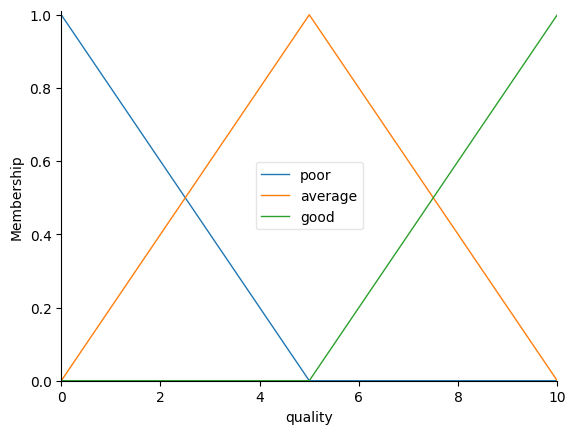

In [15]:
# [3] Fungsi keanggotaan untuk quality
quality['poor']    = fuzz.trimf(quality.universe, [0, 0, 5])
quality['average'] = fuzz.trimf(quality.universe, [0, 5, 10])
quality['good']    = fuzz.trimf(quality.universe, [5, 10, 10])

# Visualisasi
quality.view()

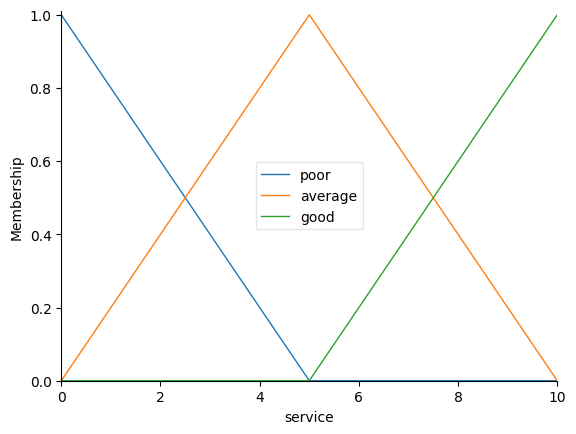

In [16]:
# [4] Fungsi keanggotaan untuk service
service['poor']    = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good']    = fuzz.trimf(service.universe, [5, 10, 10])

service.view()

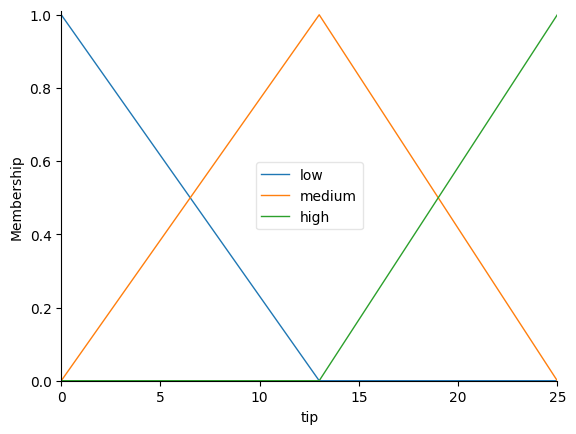

In [17]:
# [5] Fungsi keanggotaan untuk tip
tip['low']    = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high']   = fuzz.trimf(tip.universe, [13, 25, 25])

tip.view()

In [18]:
# [5] Membuat aturan dari sistem fuzzy
rule1 = ctrl.Rule(quality['poor']  | service['poor'],  tip['low'])
rule2 = ctrl.Rule(service['average'],                  tip['medium'])
rule3 = ctrl.Rule(service['good']  | quality['good'],  tip['high'])

In [19]:
# [6] Membuat objek untuk defuzzification
tipping_ctrl       = ctrl.ControlSystem([rule1, rule2, rule3])
tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

In [20]:
# [7] Memberikan input pada variabel Antecedent
tipping_simulation.input['quality'] = 6.5
tipping_simulation.input['service'] = 9.8

# Menghitung output dari sistem fuzzy
tipping_simulation.compute()

19.847607361963192


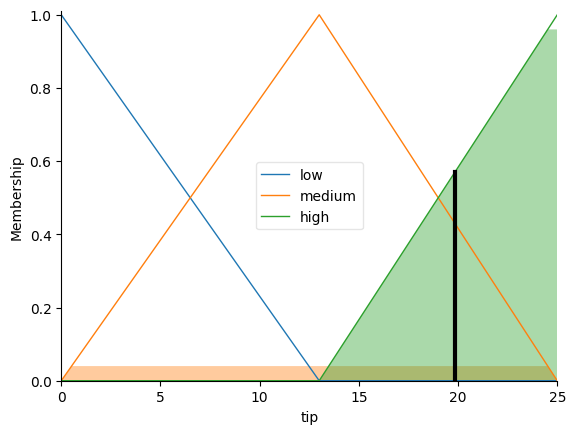

In [21]:
# [8] Menampilkan hasil & visualisasi perhitungan
print(tipping_simulation.output['tip'])
tip.view(sim=tipping_simulation)

Pada hasil diatas, *fuzzy system* memberikan rekomendasi jika nilai *quality* 6.5 dan *service* 9.8, maka *tip* yang diberikan adalah 19.84%.

## 13.4. Soal Latihan Pemrograman Scikit-Fuzzy

Ubah fungsi keanggotaan *quality* dan *service* pada soal *study case* 13.3. Fungsi keanggotaan *quality* dapat diubah seperti Gambar 22(a) dan fungsi keanggotaan *service* dapat diubah seperti Gambar 22(b).

Berdasarkan Gambar 22, nilai fungsi keanggotaan yang baru adalah:

**Quality (a)** — menggunakan `trapmf` (trapezoid):
- poor    : `trapmf [0, 0, 1, 5]`
- average : `trapmf [0, 4, 5, 8]`
- good    : `trapmf [5, 8, 10, 10]`

**Service (b)** — menggunakan `trapmf` dan `trimf`:
- poor    : `trapmf [0, 0, 2, 4]`
- average : `trapmf [2, 4, 6, 8]`
- good    : `trimf  [4, 10, 10]`

In [22]:
# Import module yang diperlukan
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [23]:
# Definisi variabel input
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')

# Definisi variabel output
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

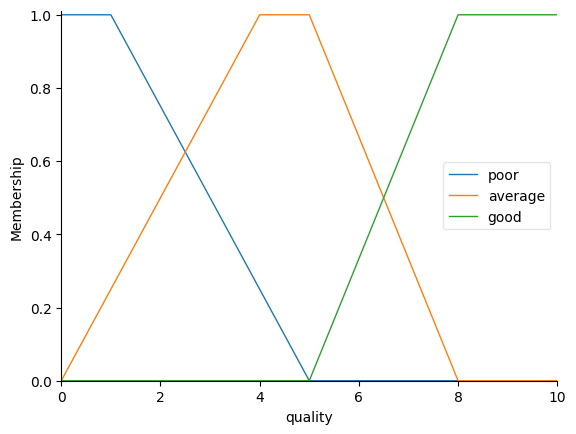

In [24]:
# Fungsi keanggotaan BARU untuk quality (Gambar 22a) - menggunakan trapmf
quality['poor']    = fuzz.trapmf(quality.universe, [0, 0, 1, 5])
quality['average'] = fuzz.trapmf(quality.universe, [0, 4, 5, 8])
quality['good']    = fuzz.trapmf(quality.universe, [5, 8, 10, 10])

# Visualisasi fungsi keanggotaan quality (Gambar 22a)
quality.view()

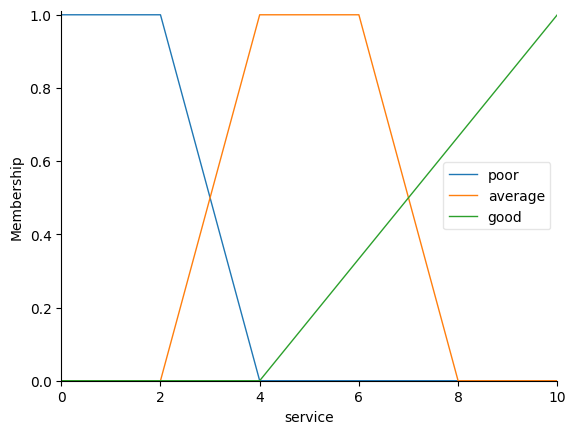

In [25]:
# Fungsi keanggotaan BARU untuk service (Gambar 22b) - menggunakan trapmf dan trimf
service['poor']    = fuzz.trapmf(service.universe, [0, 0, 2, 4])
service['average'] = fuzz.trapmf(service.universe, [2, 4, 6, 8])
service['good']    = fuzz.trimf(service.universe,  [4, 10, 10])

# Visualisasi fungsi keanggotaan service (Gambar 22b)
service.view()

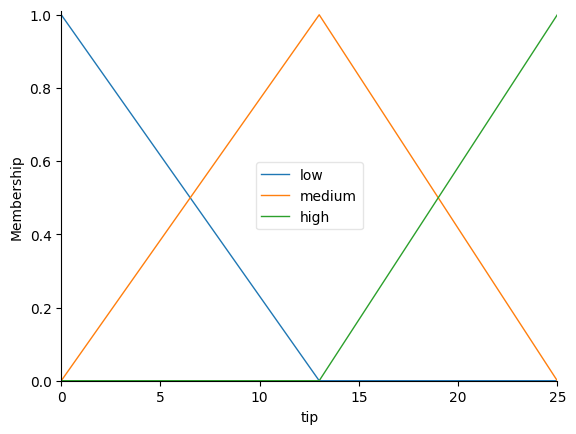

In [26]:
# Fungsi keanggotaan untuk tip (sama seperti study case 13.3)
tip['low']    = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high']   = fuzz.trimf(tip.universe, [13, 25, 25])

tip.view()

In [27]:
# Membuat aturan dari sistem fuzzy (sama seperti study case 13.3)
rule1 = ctrl.Rule(quality['poor']  | service['poor'],  tip['low'])
rule2 = ctrl.Rule(service['average'],                  tip['medium'])
rule3 = ctrl.Rule(service['good']  | quality['good'],  tip['high'])

In [28]:
# Membuat objek untuk defuzzification
tipping_ctrl       = ctrl.ControlSystem([rule1, rule2, rule3])
tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

In [29]:
# Memberikan input pada variabel Antecedent
tipping_simulation.input['quality'] = 6.5
tipping_simulation.input['service'] = 9.8

# Menghitung output dari sistem fuzzy
tipping_simulation.compute()

20.995698924731183


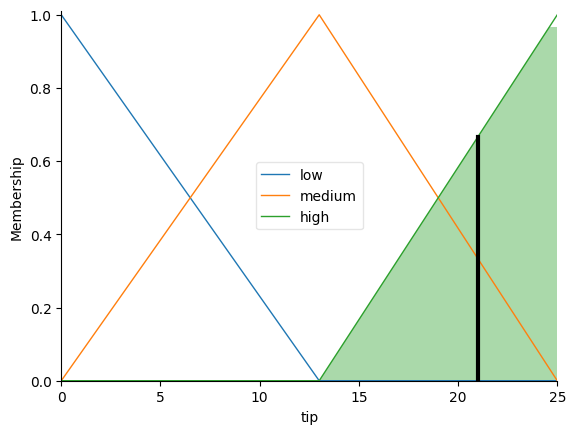

In [30]:
# Menampilkan hasil & visualisasi perhitungan
print(tipping_simulation.output['tip'])
tip.view(sim=tipping_simulation)